In [86]:
import sys
sys.path.append('..')
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate  # TwoLocal, ZZFeatureMap, etc
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from numbers import Number
from qiskit.synthesis import LieTrotter
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt

In [ ]:
service = QiskitRuntimeService(token='',
                               channel='ibm_quantum',
                               instance='client-enablement/solutions/demo-testing')

In [ ]:
#service = QiskitRuntimeService()
backend = service.backend("ibm_torino")

# target = backend.target
# cm = target.build_coupling_map()
cm = backend.coupling_map
deg3_qubits = [
    idx for idx, row in enumerate(cm.distance_matrix) if list(row).count(1) == 3
]
edge_qubits = [0, 2, 6, 10, 18, 32, 37, 51, 56, 70, 75, 89, 94, 108, 116, 120, 124]
full_layering = [
    [edge for edge in cm.get_edges() if d3q in edge]
    for d3q in deg3_qubits + edge_qubits
] # find all edges that connect any of the qubits in deg3 and edge qubits.
ent_map = sum(
    [[layer[idx] for layer in full_layering if idx < len(layer)] for idx in range(3)],
    [],
) # concatenate in one array all the edges in full_layering above that connect 1,2, or 3 qubits out of deg3 + edge qubits.

def Heisenberg(J, n, ent_map):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    return H.chop()

qubit_subset = [0, 1, 2, 3, 4, 14, 15, 18, 19, 20, 21, 22]
remap = {q: i for q, i in zip(qubit_subset, range(len(qubit_subset)))}
# filtering the entanglement map such that only the desired qubits are present.
f_ent_map = []
for a, b in ent_map:
    if a in qubit_subset and b in qubit_subset:
        f_ent_map.append((remap[a], remap[b])) #maps it back to the qubits numbered 0 to 11.
H = Heisenberg(1, 12, f_ent_map)


def prep_psi_0_with_checkpoints(qc: QuantumCircuit):
    qc.cx(12, 9)
    #
    qc.cx(9,10)
    #
    qc.cx(10,11)
    qc.cx(9,8)
    #
    qc.cx(11,6)
    qc.cx(8,7)
    #
    qc.cx(7,5)
    qc.cx(6,4)
    #
    qc.cx(4,3)
    qc.cx(5,0)
    #
    qc.cx(3,2)
    #make checkpoints
    qc.cx(11, 17)
    qc.cx(4, 16)
    qc.cx(2, 15)
    qc.cx(0, 14)
    qc.cx(7, 13)
    #undo entanglement on undesired qubits
    qc.cx(2,3)
    qc.cx(4,6)
    qc.cx(11,10)
    qc.cx(9,8)
    qc.cx(7,5)
    return qc

def prep_psi_0_by_0_with_checkpoints(qc: QuantumCircuit):
    qc.cx(12, 9, ctrl_state='0')
    qc.cx(17, 11, ctrl_state='0')
    qc.cx(16,4, ctrl_state='0')
    qc.cx(15,2, ctrl_state='0')
    qc.cx(14,0, ctrl_state='0')
    qc.cx(13,7, ctrl_state='0')
    return qc



In [ ]:
# from qiskit_aer import StatevectorSimulator
# sv=StatevectorSimulator()
# qc =QuantumCircuit(13)
# qc.h(12)

# qc.cx(12, 9)
    
# qc.cx(9,10)  
# qc.cx(10,11)
# qc.cx(11,6)
# qc.cx(6,4)
# qc.cx(4,3)
# qc.cx(3,2)

# qc.cx(9,8)
# qc.cx(8,7)    
# qc.cx(7,5)
# qc.cx(5,0)

    


# #make checkpoints
# # qc.cx(11, 17)
# # qc.cx(4, 16)
# # qc.cx(2, 15)
# # qc.cx(0, 14)
# # qc.cx(7, 13)
# #undo entanglement on undesired qubits
# # qc.cx(2,3)
# # qc.cx(4,6)
# # qc.cx(11,10)
# # qc.cx(9,8)
# # qc.cx(7,5)

# qc.draw("mpl")

# qc.measure_all()

# sv_job=sv.run(qc, shots=10000)
# sv_job.result().get_counts()

In [167]:
from qiskit.transpiler import generate_preset_pass_manager 
# from qiskit.transpiler.passes import HLSConfig
# from qiskit_ibm_transpiler.transpiler_service import TranspilerService

# config = HLSConfig(PauliEvolution=[("default", {"upto_phase": True})])

# ts = TranspilerService(
#     backend_name="ibm_quebec",
#     ai="true",
#     optimization_level=3
# )


circuits = np.ndarray([10,10], dtype= QuantumCircuit)
H_tilde = np.zeros([10,10], dtype=complex)
S_tilde = np.zeros([10,10], dtype=complex)
synth = LieTrotter(reps = 1)
delta_t = np.pi/40
time_evol = PauliEvolutionGate(H, delta_t, synthesis = synth)

real_obs_H = SparsePauliOp('XXXXXX', 1) ^ H
imag_obs_H = SparsePauliOp('YXXXXX', 1) ^ H
real_obs_S = SparsePauliOp('XXXXXX', 1) ^ SparsePauliOp('I'*12, 1)
imag_obs_S = SparsePauliOp('YXXXXX', 1) ^ SparsePauliOp('I'*12, 1)


for j in range(10):
    for i in range(j+1):
        m = i
        n = j - i
        qc = QuantumCircuit(18)
        qc.h(12)
        qc = prep_psi_0_with_checkpoints(qc)
        for t in range(n):
            qc.append(time_evol, range(12))
        qc = prep_psi_0_by_0_with_checkpoints(qc)
        for t in range(m):
            qc.append(time_evol, range(12))
        circuits[i][j] = qc.copy()

#pm_tr = generate_preset_pass_manager(backend=backend, optimization_level=3,hls_config=config)
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

circs = []
for i in range(10):
    circs.append([])
    for j in range(10):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]

# circ_trial=pm.run(circuits[9][9])
# circ_ref= pm_tr.run(circuits[9][9])

# circ_ai_trial = ts.run(circuits[9][9])


In [191]:
#NO ANSATZ
#basis state has energy -12
from qiskit_ibm_runtime import EstimatorV2, Batch
pub1=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[0:2] for circ in circ_list]
pub2=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[2:4] for circ in circ_list]
pub3=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[4:6] for circ in circ_list]
pub4=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[6:8] for circ in circ_list]
pub5=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[8:10] for circ in circ_list]

with Batch(backend=backend) as batch:
    estimator = EstimatorV2(mode=batch)
    estimator.options.default_shots = 10000
    estimator.options.resilience_level = 2
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = 'XpXm'
#     estimator.options.experimental = {"execution": {"fast_parametric_update": True}}
#     estimator.options.experimental = {
#     "execution_path": "ouroboros"
# }
    #estimator.options.execution.init_qubits=init_qubits
    #estimator.options.resilience.zne_mitigation = True
    #estimator.options.resilience.zne.amplifier = 'pea'
    #estimator.options.twirling.enable_gates = True
    # estimator.options.twirling.num_randomizations = 32
    # estimator.options.twirling.shots_per_randomization = 350
    #estimator.options.twirling.strategy = 'active'
    # estimator.options.resilience.measure_mitigation = True
    # estimator.options.resilience.measure_noise_learning.num_randomizations = 32
    # estimator.options.resilience.measure_noise_learning.shots_per_randomization = (
    #     350
    # )
    #est_job_1 = estimator.run(pub1)
    #est_job_2 = estimator.run(pub2)
    est_job_3 = estimator.run(pub3)
    #est_job_4 = estimator.run(pub4)
    #est_job_5 = estimator.run(pub5)

   

In [169]:
est_job_1.job_id()

'cz7fa00p6030008d0hy0'

In [170]:
est_job_2.job_id()

'cz7fa1810wx0008c1cg0'

In [192]:
est_job_3.job_id()

'cz7nzfnp6030008d19d0'

In [172]:
est_job_4.job_id()

'cz7fa2r39f40008syr20'

In [173]:
est_job_5.job_id()

'cz7fa38kvm9g008grkdg'

In [193]:
est_job_1_results = service.job('cz7fa00p6030008d0hy0').result()

est_job_2_results = service.job('cz7fa1810wx0008c1cg0').result()

est_job_3_results = service.job('cz7nzfnp6030008d19d0').result()

est_job_4_results = service.job('cz7fa2r39f40008syr20').result()

est_job_5_results = service.job('cz7fa38kvm9g008grkdg').result()


In [194]:
H_tilde[0,0] = est_job_1_results[0].data.evs[0] + 1j * est_job_1_results[0].data.evs[1]
S_tilde[0,0] = est_job_1_results[0].data.evs[2] + 1j * est_job_1_results[0].data.evs[3]

In [195]:
H_tilde[0,0]

np.complex128(-14.921140670324249+0.4472466370469959j)

In [196]:
S_tilde[0,0]

np.complex128(1.072684055403698+0.03821359321120672j)

In [197]:
idx=0
for i in range(2):
    for j in range(10):
            H_tilde[i,j] = est_job_1_results[idx].data.evs[0] + 1j * est_job_1_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_1_results[idx].data.evs[2] + 1j * est_job_1_results[idx].data.evs[3]
            idx+=1

idx=0
for i in range(2,4):
    for j in range(10):
            H_tilde[i,j] = est_job_2_results[idx].data.evs[0] + 1j * est_job_2_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_2_results[idx].data.evs[2] + 1j * est_job_2_results[idx].data.evs[3]
            idx+=1

idx=0
for i in range(4,6):
    for j in range(10):
            H_tilde[i,j] = est_job_3_results[idx].data.evs[0] + 1j * est_job_3_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_3_results[idx].data.evs[2] + 1j * est_job_3_results[idx].data.evs[3]
            idx+=1

idx=0
for i in range(6,8):
    for j in range(10):
            H_tilde[i,j] = est_job_4_results[idx].data.evs[0] + 1j * est_job_4_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_4_results[idx].data.evs[2] + 1j * est_job_4_results[idx].data.evs[3]
            idx+=1

idx=0
for i in range(8,10):
    for j in range(10):
            H_tilde[i,j] = est_job_5_results[idx].data.evs[0] + 1j * est_job_5_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_5_results[idx].data.evs[2] + 1j * est_job_5_results[idx].data.evs[3]
            idx+=1

In [198]:
[np.real(H_tilde[x][x]) for x in range(len(H_tilde))]

[np.float64(-14.921140670324249),
 np.float64(-10.68530424973278),
 np.float64(-5.178581683970968),
 np.float64(-6.765663911841944),
 np.float64(-0.5052491764299086),
 np.float64(-0.28713200058123134),
 np.float64(-1.5031882309487314),
 np.float64(-0.9496563143960349),
 np.float64(-1.002992042517242),
 np.float64(-0.6405819535778264)]

In [199]:
H_tilde[2][:]

array([ 0.4123918 +1.3582021j ,  0.27217455-0.68394968j,
       -5.17858168-0.44521405j,  0.46318846-2.00683461j,
        0.20689754+0.6759732j , -0.29070735+0.27547537j,
        0.63523989+0.06639658j, -0.02945309+0.40000891j,
        0.07156409+0.25127735j, -0.62264884+0.26450437j])

In [200]:
[np.real(S_tilde[x][x]) for x in range(len(S_tilde))]

[np.float64(1.072684055403698),
 np.float64(0.8992379366815062),
 np.float64(0.3223901621313274),
 np.float64(1.0732718136050616),
 np.float64(0.08829557083650028),
 np.float64(0.0617270503666432),
 np.float64(0.09337102909954892),
 np.float64(0.21465380119077448),
 np.float64(0.20604353356220328),
 np.float64(0.08772477473529079)]

1
2
3
4
5
6
7
8
9
10


/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Ground state energy')

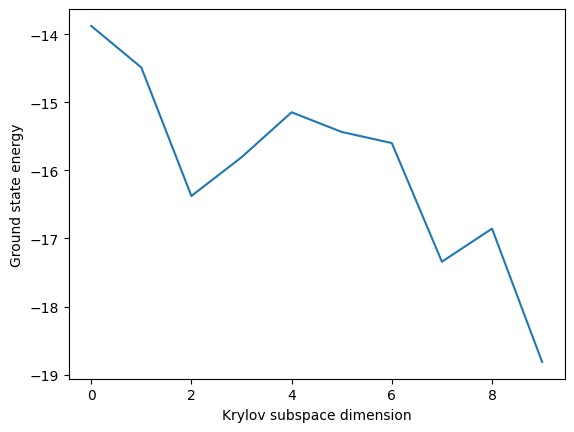

In [201]:
def truncation(threshold, S):
    eigvals, eigvecs = np.linalg.eig(S)
    idx = eigvals.argsort()[::-1]   
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:,idx] # the eigenvecs are normalized by default!
    D = len(eigvals)
    truncated_eigvals = []
    truncated_eigvecs = []
    #make truncated matrix whose rows are eigenvectors of S with eigval above threshold
    for i in range(D):
        if eigvals[i] >= threshold:
            truncated_eigvals.append(eigvals[i])
            truncated_eigvecs.append(eigvecs[i])
    truncated_eigvals = np.array(truncated_eigvals)
    truncated_eigvecs = np.array(truncated_eigvecs).T    
    return truncated_eigvecs

#solve diagonalization problem, find dependence on dimension of krylov subspace. 
def E_vs_D(H_tilde, S_tilde, threshold_slope):
    GSEs = []
    ground_states = []
    for d in range(1, len(S_tilde)+1):
        epsilon = threshold_slope*d
        H_temp = H_tilde[0:d, 0:d]
        S_temp = S_tilde[0:d, 0:d]
        V_eps = truncation(epsilon, S_temp)
        #solve GEVP
        A = V_eps.conj().T @ H_temp @ V_eps # the eigenvec is V are normalied.
        B = V_eps.conj().T @ S_temp @ V_eps
        print(A.shape[0])
        E, c = scipy.linalg.eig(a = A, b = B)
        idx = E.argsort()[::-1]   
        eigvals = E[idx]
        eigvecs = c[:,idx]
        GSEs.append(eigvals[-1])
        ground_states.append(eigvecs[:,-1])
    return GSEs, ground_states, V_eps
GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-8)
plt.plot(GSEs) # Ground-state energies
# V_eps is the truncation matrix, removes smallest singular values from S-tilde.
plt.xlabel('Krylov subspace dimension')
plt.ylabel('Ground state energy')